In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [3]:
app = pd.read_csv('/home/akash/Desktop/predictive_prjct_1/application_train (2).csv')
bureau = pd.read_csv('/home/akash/Desktop/predictive_prjct_1/bureau.csv')

In [4]:
print(app.head())

   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...                 0             

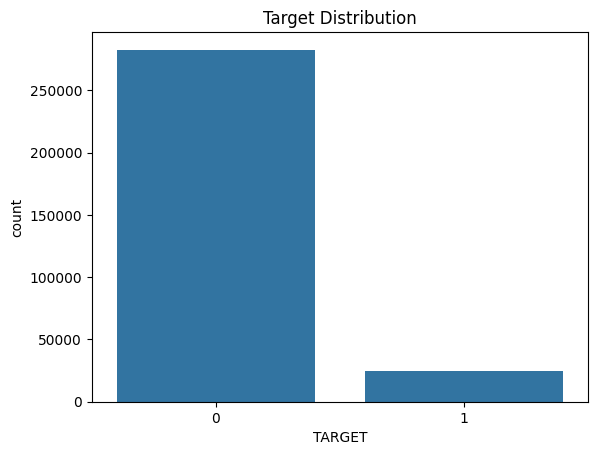

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='TARGET', data=app)
plt.title("Target Distribution")
plt.show()

print(app['TARGET'].value_counts(normalize=True))

In [7]:
corr = app.corr(numeric_only=True)['TARGET'].sort_values(ascending=False)
print(corr.head(10))
print("*"*50)
print(corr.tail(10))

TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
Name: TARGET, dtype: float64
**************************************************
ELEVATORS_AVG                -0.034199
REGION_POPULATION_RELATIVE   -0.037227
AMT_GOODS_PRICE              -0.039645
FLOORSMAX_MODE               -0.043226
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_AVG                -0.044003
DAYS_EMPLOYED                -0.044932
EXT_SOURCE_1                 -0.155317
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_3                 -0.178919
Name: TARGET, dtype: float64


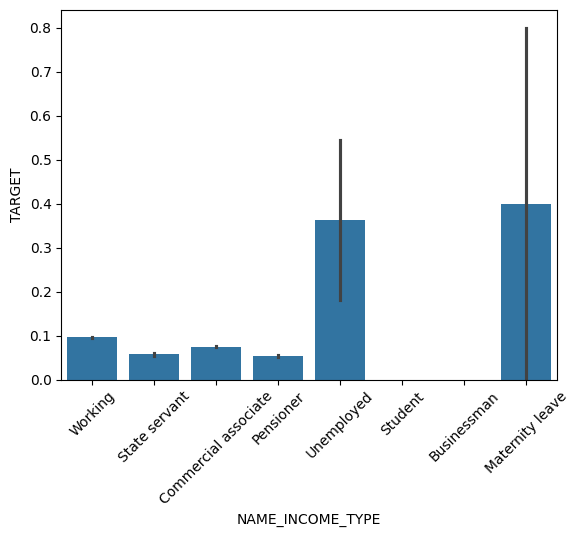

In [8]:
sns.barplot(x='NAME_INCOME_TYPE', y='TARGET', data=app)
plt.xticks(rotation=45)
plt.show()

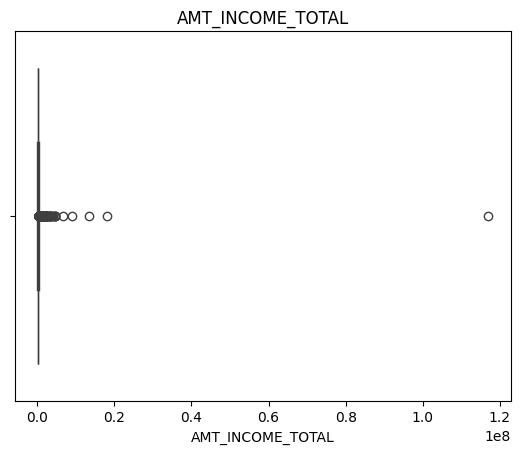

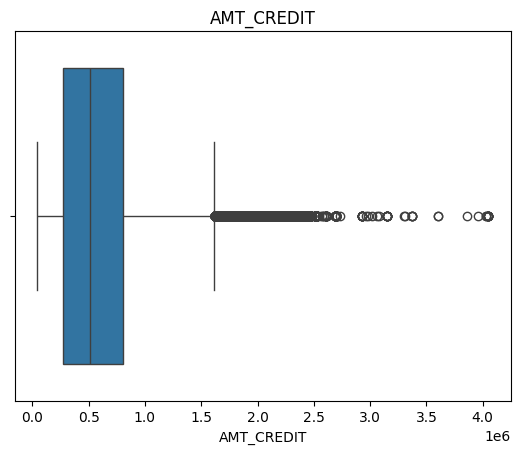

In [9]:
for col in ['AMT_INCOME_TOTAL', 'AMT_CREDIT']:
    sns.boxplot(x=app[col])
    plt.title(col)
    plt.show()

In [10]:
# Ratios (IMPORTANT)
app['credit_income_ratio'] = app['AMT_CREDIT'] / app['AMT_INCOME_TOTAL']
app['annuity_income_ratio'] = app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL']
app['credit_goods_ratio'] = app['AMT_CREDIT'] / app['AMT_GOODS_PRICE']
app['income_per_person'] = app['AMT_INCOME_TOTAL'] / app['CNT_FAM_MEMBERS']

# Replace inf
app.replace([np.inf, -np.inf], np.nan, inplace=True)

/tmp/ipykernel_12435/4181849145.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['credit_income_ratio'] = app['AMT_CREDIT'] / app['AMT_INCOME_TOTAL']
/tmp/ipykernel_12435/4181849145.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['annuity_income_ratio'] = app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL']
/tmp/ipykernel_12435/4181849145.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at o

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,credit_income_ratio,annuity_income_ratio,credit_goods_ratio,income_per_person
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,1.0,2.007889,0.121978,1.158397,202500.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,4.790750,0.132217,1.145199,135000.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.000000,0.100000,1.000000,67500.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,2.316167,0.219900,1.052803,67500.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,4.222222,0.179963,1.000000,121500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.617143,0.174971,1.132000,157500.0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,NaN,NaN,NaN,NaN,NaN,NaN,3.743750,0.166687,1.198000,72000.0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,1.0,0.0,0.0,1.0,0.0,1.0,4.429176,0.195941,1.158400,153000.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.164368,0.118158,1.158394,85500.0


In [11]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT_SUM': ['mean', 'sum'],
    'AMT_CREDIT_SUM_DEBT': ['mean', 'sum'],
    'CREDIT_ACTIVE': 'count'
})

bureau_agg.columns = ['_'.join(col) for col in bureau_agg.columns]
bureau_agg.reset_index(inplace=True)

# Merge with application data
df = app.merge(bureau_agg, on='SK_ID_CURR', how='left')

In [12]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

/tmp/ipykernel_12435/2455914683.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [13]:
df.fillna(0, inplace=True)

X = df.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)